In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(ROOT))

from src.paths import OUTPUT, FIG_OUTPUT

# 2.x Model

In [2]:
# Load each 2.x metrics_summary file separately (filtered to 1 added feature)

# 2.0-fc-rand-A-colab
df_2_0_fc_rand_A_colab = pd.read_csv(OUTPUT / '2.0-fc-rand-A-colab/01-run/metrics_summary.csv')
df_2_0_fc_rand_A_colab = df_2_0_fc_rand_A_colab[df_2_0_fc_rand_A_colab['added_features'] == 1].copy()

# 2.1-fc-rand-B-colab
df_2_1_fc_rand_B_colab = pd.read_csv(OUTPUT / '2.1-fc-rand-B-colab/01-run/metrics_summary.csv')
df_2_1_fc_rand_B_colab = df_2_1_fc_rand_B_colab[df_2_1_fc_rand_B_colab['added_features'] == 1].copy()

# 2.2-fc-rand-C-colab
df_2_2_fc_rand_C_colab = pd.read_csv(OUTPUT / '2.2-fc-rand-C-colab/01-run/metrics_summary.csv')
df_2_2_fc_rand_C_colab = df_2_2_fc_rand_C_colab[df_2_2_fc_rand_C_colab['added_features'] == 1].copy()

# 2.3-fc-rand-D-colab
df_2_3_fc_rand_D_colab = pd.read_csv(OUTPUT / '2.3-fc-rand-D-colab/01-run/metrics_summary.csv')
df_2_3_fc_rand_D_colab = df_2_3_fc_rand_D_colab[df_2_3_fc_rand_D_colab['added_features'] == 1].copy()

# 2.3.1-fc-rand-D-colab-ivlag
df_2_3_1_fc_rand_D_colab_ivlag = pd.read_csv(OUTPUT / '2.3.1-fc-rand-D-colab-ivlag/01-run/metrics_summary.csv')
df_2_3_1_fc_rand_D_colab_ivlag = df_2_3_1_fc_rand_D_colab_ivlag[df_2_3_1_fc_rand_D_colab_ivlag['added_features'] == 1].copy()


## AVG gain from Feature Combinations

In [3]:
from collections import defaultdict

# Load metrics from splits A, B, C
SPLITS = {
    "A": OUTPUT / "2.0-fc-rand-A-colab/01-run/metrics_summary.csv",
    "B": OUTPUT / "2.1-fc-rand-B-colab/01-run/metrics_summary.csv",
    "C": OUTPUT / "2.2-fc-rand-C-colab/01-run/metrics_summary.csv",
}

def get_extra_feats(model_name):
    """Extract feature set from model name."""
    if model_name == "3F":
        return frozenset()
    if model_name.startswith("3F+"):
        return frozenset(model_name[3:].split("+"))
    return frozenset([model_name])

def parse_gain(s):
    """Parse gain string, removing % sign."""
    try:
        return float(str(s).strip().rstrip("%"))
    except ValueError:
        return None

# Build combo_gains: {feature_set -> {split -> gain}}
combo_gains = defaultdict(dict)
for split, path in SPLITS.items():
    df = pd.read_csv(path)
    df = df[df["Model"] != "Analytic"]
    for _, row in df.iterrows():
        gain = parse_gain(row.get("Gain_vs_Analytic", ""))
        key = get_extra_feats(row["Model"])
        combo_gains[key][split] = gain

# Compute per-feature marginal gains
gain_lookup = {}
for split, path in SPLITS.items():
    df = pd.read_csv(path)
    df = df[df["Model"] != "Analytic"]
    for _, row in df.iterrows():
        gain = parse_gain(row.get("Gain_vs_Analytic", ""))
        if gain is not None:
            key = get_extra_feats(row["Model"])
            gain_lookup[(split, key)] = gain

marginal = defaultdict(list)
for split in SPLITS:
    all_combos = [k for (s, k) in gain_lookup if s == split]
    for combo in all_combos:
        for feat in combo:
            combo_without = combo - {feat}
            if (split, combo_without) in gain_lookup:
                delta = gain_lookup[(split, combo)] - gain_lookup[(split, combo_without)]
                marginal[feat].append(delta)

# Build feature stats
feat_stats = {}
for feat, vals in marginal.items():
    feat_stats[feat] = {
        "mean": np.mean(vals),
        "median": np.median(vals),
        "std": np.std(vals),
    }

# Build records for each combo
records = []
for combo, gains in combo_gains.items():
    valid_gains = [g for g in gains.values() if g is not None]
    avg = sum(valid_gains) / len(valid_gains) if valid_gains else 0.0
    
    if combo:
        avg_marginal = np.mean([feat_stats[f]["mean"] for f in combo])
        avg_median = np.mean([feat_stats[f]["median"] for f in combo])
        avg_std = np.mean([feat_stats[f]["std"] for f in combo])
        n_feats = len(combo)
    else:
        avg_marginal = avg_median = avg_std = 0.0
        n_feats = 0
    
    records.append({
        "extra_features": "+".join(sorted(combo)) if combo else "(none)",
        "avg_gain": avg,
        "avg_marginal_gain": avg_marginal,
        "avg_median_marginal": avg_median,
        "avg_std": avg_std,
        "n_features": n_feats,
        "gain_A": gains.get("A"),
        "gain_B": gains.get("B"),
        "gain_C": gains.get("C"),
    })

# Build and sort table
avg_gain = (
    pd.DataFrame(records)
    .sort_values("avg_gain", ascending=False)
    .reset_index(drop=True)
)
avg_gain.index += 1

# Save to CSV
#avg_gain.to_csv(FIG_OUTPUT / "2.x-avg-feature-gain-A-B-C.csv")

# Display with color-coded columns
display(avg_gain[["extra_features", "avg_gain", "avg_marginal_gain", "avg_median_marginal", "avg_std", "n_features", "gain_A", "gain_B", "gain_C"]]
    .style.format({
        "avg_gain": "{:.2f}",
        "avg_marginal_gain": "{:+.2f}",
        "avg_median_marginal": "{:+.2f}",
        "avg_std": "{:.2f}",
        "n_features": "{:.0f}",
        "gain_A": "{:.2f}",
        "gain_B": "{:.2f}",
        "gain_C": "{:.2f}",
    })
    .background_gradient(subset=["avg_gain", "avg_marginal_gain"], cmap="RdYlGn")
)

,extra_features,avg_gain,avg_marginal_gain,avg_median_marginal,avg_std,n_features,gain_A,gain_B,gain_C
1,gamma+theta+vix_lag+vix_mom+vix_mom_lag,38.96,+7.61,+7.00,8.52,5,44.72,24.56,47.61
2,gamma+rho+vix_lag+vix_mom+vix_mom_lag,36.98,+7.00,+6.50,8.49,5,45.57,25.48,39.90
3,gamma+rho+theta+vega+vix_lag+vix_mom+vix_mom_lag,36.92,+6.31,+5.82,8.47,7,45.47,22.64,42.66
4,theta+vega+vix_lag+vix_mom+vix_mom_lag,35.84,+6.85,+6.32,8.40,5,45.15,25.72,36.66
5,gamma+vega+vix_lag+vix_mom+vix_mom_lag,35.35,+6.81,+6.31,8.49,5,42.87,23.51,39.67
6,gamma+rho+theta+vix_lag+vix_mom+vix_mom_lag,33.39,+6.92,+6.39,8.49,6,44.03,14.78,41.35
7,rho+theta+vix_lag+vix_mom+vix_mom_lag,33.09,+7.03,+6.51,8.39,5,42.82,24.78,31.66
8,gamma+theta+vega+vix_mom+vix_mom_lag,32.87,+6.47,+5.96,8.51,5,40.01,21.72,36.87
9,gamma+theta+vix_mom+vix_mom_lag,32.20,+7.43,+6.85,8.55,4,37.36,18.83,40.40
10,gamma+rho+theta+vix_lag+vix_mom,32.17,+6.81,+6.31,8.49,5,40.72,17.76,38.03


## Marginal Gain over 3F Baseline

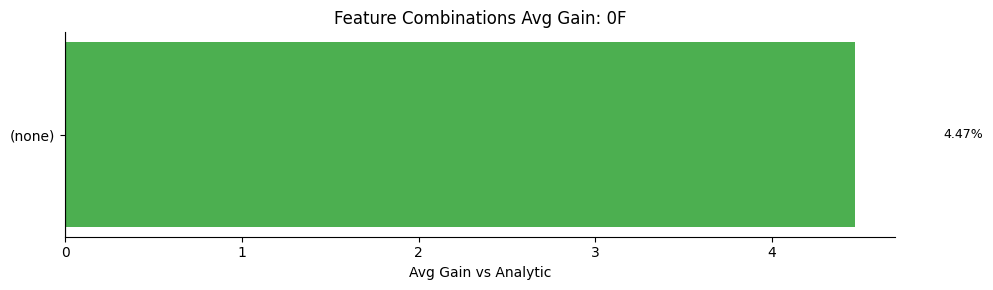

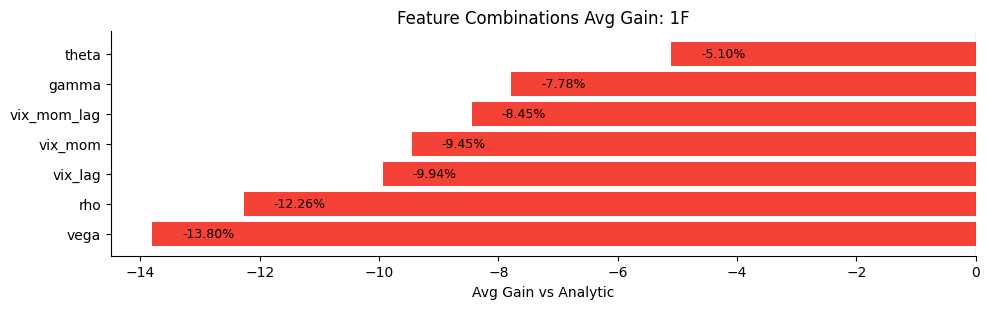

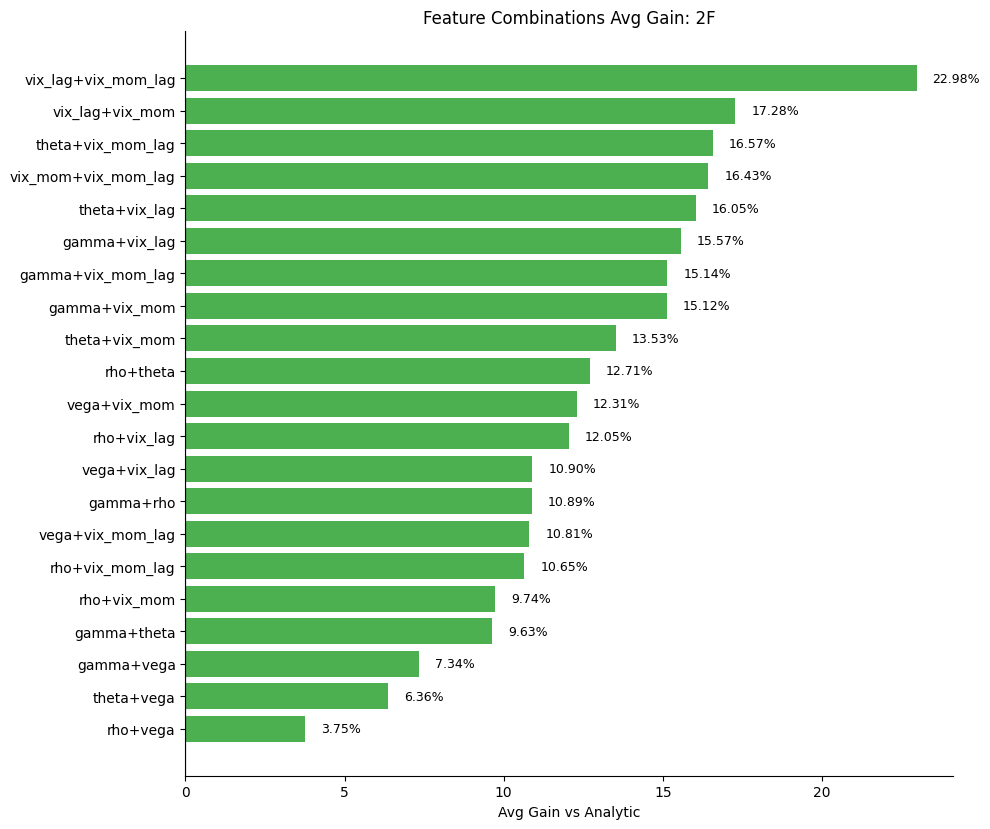

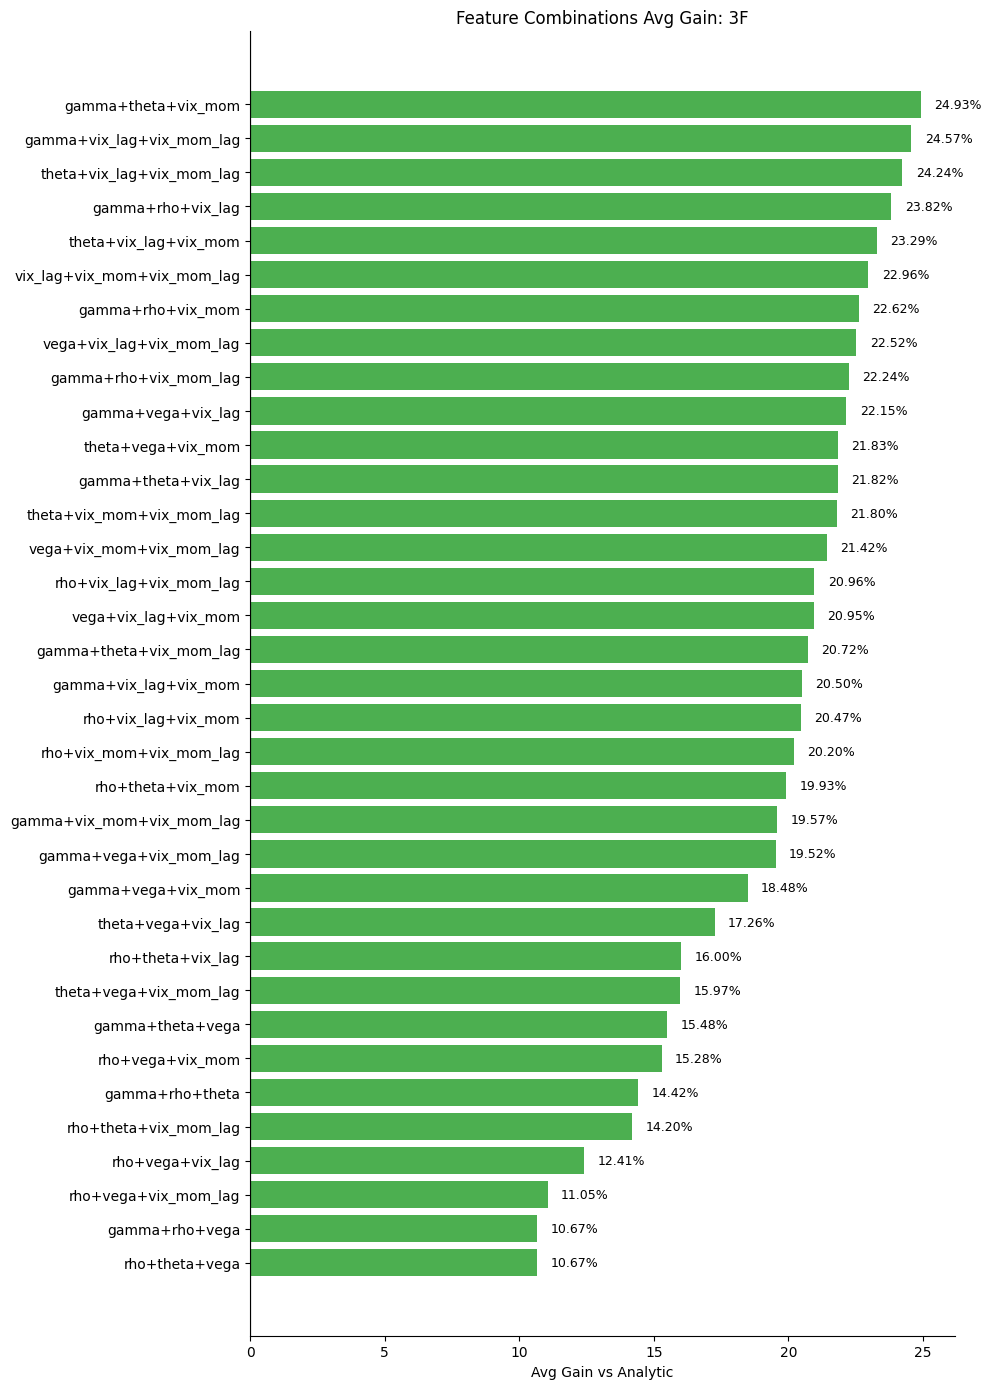

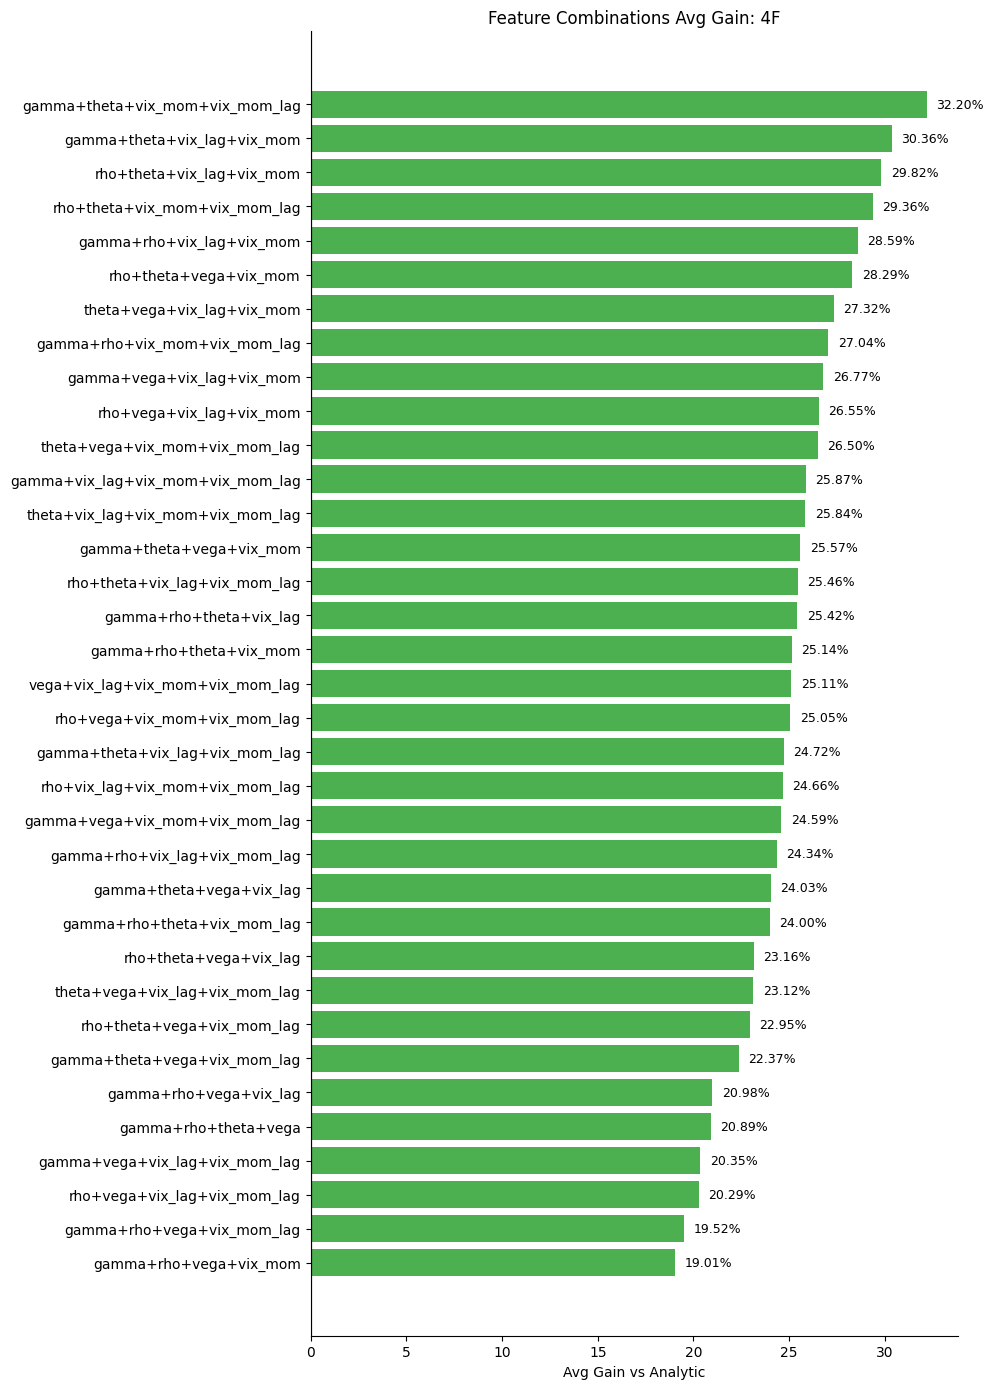

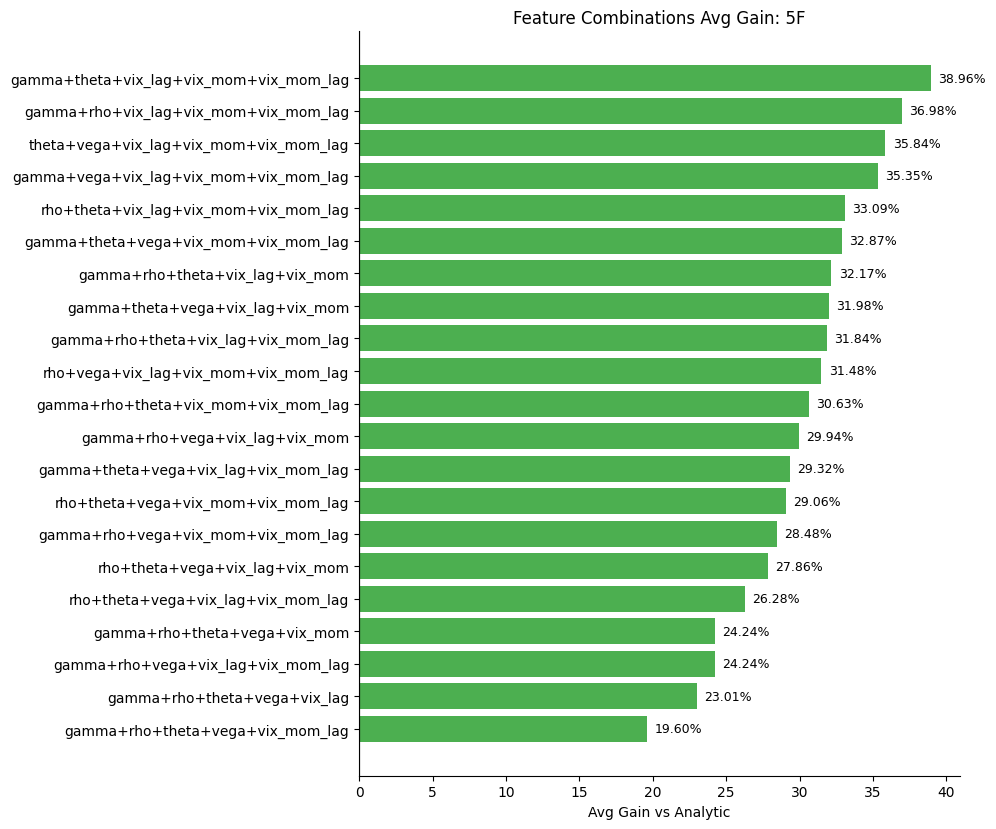

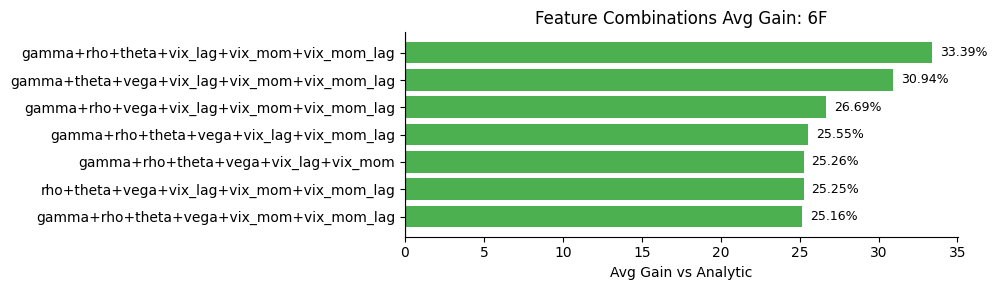

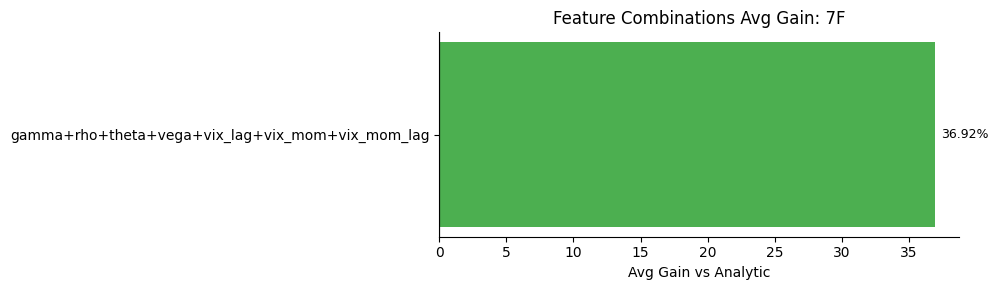

In [4]:
# Create charts grouped by N(features)
# Get unique feature counts, sorted
feature_counts = sorted(avg_gain["n_features"].unique())

# Create a chart for each feature count
for n_feat in feature_counts:
    data = avg_gain[avg_gain["n_features"] == n_feat].copy()
    data = data.sort_values("avg_gain", ascending=True)
    
    if len(data) == 0:
        continue
    
    fig, ax = plt.subplots(figsize=(10, max(3, len(data) * 0.4)))
    colors = ["#4caf50" if v >= 0 else "#f44336" for v in data["avg_gain"]]
    bars = ax.barh(data["extra_features"], data["avg_gain"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    
    for bar, val in zip(bars, data["avg_gain"]):
        pad = 0.5
        # Always place label to the right of the bar
        ha  = "left"
        x   = val + pad
        ax.text(x, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}%", va="center", ha=ha, fontsize=9)
    
    ax.set_xlabel("Avg Gain vs Analytic")
    ax.set_title(f"Feature Combinations Avg Gain: {int(n_feat)}F")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    #plt.savefig(FIG_OUTPUT / f"2.x-combos-{int(n_feat)}F.png", dpi=150, bbox_inches="tight")
    plt.show()

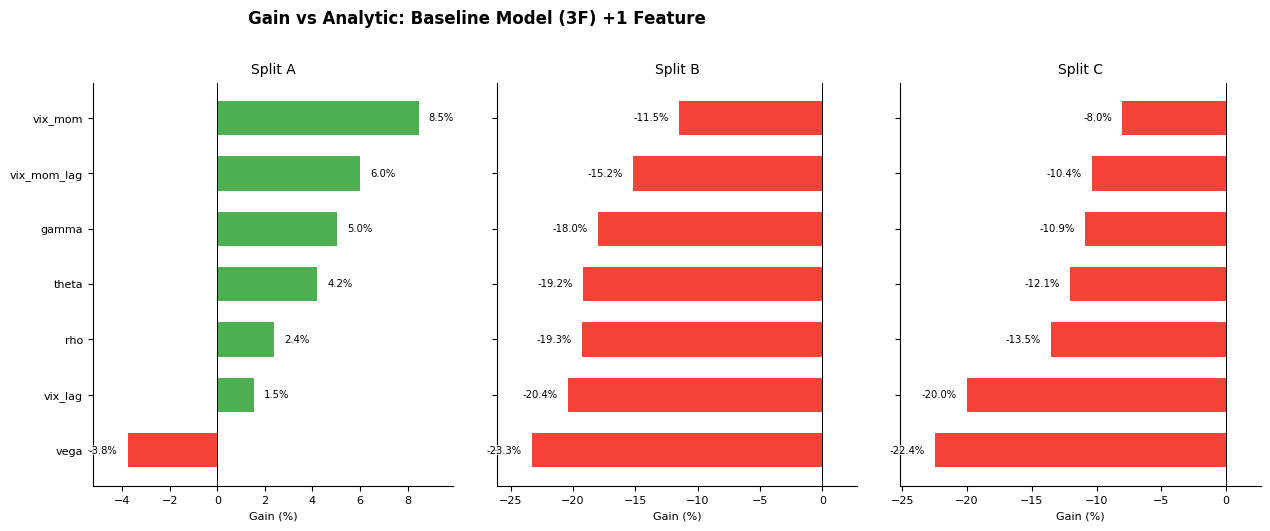

In [5]:
# Compact 1F - 3 splits side-by-side (slide-ready)
splits       = ["gain_A", "gain_B", "gain_C"]
split_labels = ["Split A", "Split B", "Split C"]
one_f = avg_gain[avg_gain["n_features"] == 1].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5.6), sharey=False)
fig.suptitle("Gain vs Analytic: Baseline Model (3F) +1 Feature", fontsize=12, fontweight="bold", y=0.97)

for idx, (ax, split, label) in enumerate(zip(axes, splits, split_labels)):
    data = one_f[one_f[split].notna()].sort_values(split, ascending=True)
    y_labels = data["extra_features"].astype(str).str.replace("+", " + ", regex=False)

    colors = ["#4caf50" if v >= 0 else "#f44336" for v in data[split]]
    bars = ax.barh(y_labels, data[split], color=colors, height=0.62)
    ax.axvline(0, color="black", linewidth=0.7)

    x_min = min(data[split].min(), 0)
    x_max = max(data[split].max(), 0)
    x_span = max(x_max - x_min, 1.0)
    x_pad = max(0.8, x_span * 0.12)
    left_lim = x_min - x_pad
    right_lim = x_max + x_pad
    ax.set_xlim(left_lim, right_lim)

    label_offset = max(0.22, x_span * 0.035)
    zero_guard = max(0.35, x_span * 0.06)
    edge_margin = max(0.12, x_span * 0.02)

    for bar, val in zip(bars, data[split]):
        if val >= 0:
            x_text = max(val + label_offset, zero_guard)
            ha = "left"
        else:
            x_text = min(val - label_offset, -zero_guard)
            ha = "right"

        x_text = min(max(x_text, left_lim + edge_margin), right_lim - edge_margin)

        ax.text(
            x_text,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center",
            ha=ha,
            fontsize=7.2,
            clip_on=False,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.12),
        )

    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Gain (%)", fontsize=8)
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    if idx > 0:
        ax.tick_params(axis="y", labelleft=False)
    ax.spines[["top", "right"]].set_visible(False)

fig.subplots_adjust(left=0.26, right=0.99, wspace=0.12, top=0.84, bottom=0.12)
plt.savefig(FIG_OUTPUT / "2.x-1F-splits-ABC.png", dpi=150, bbox_inches="tight")
plt.show()



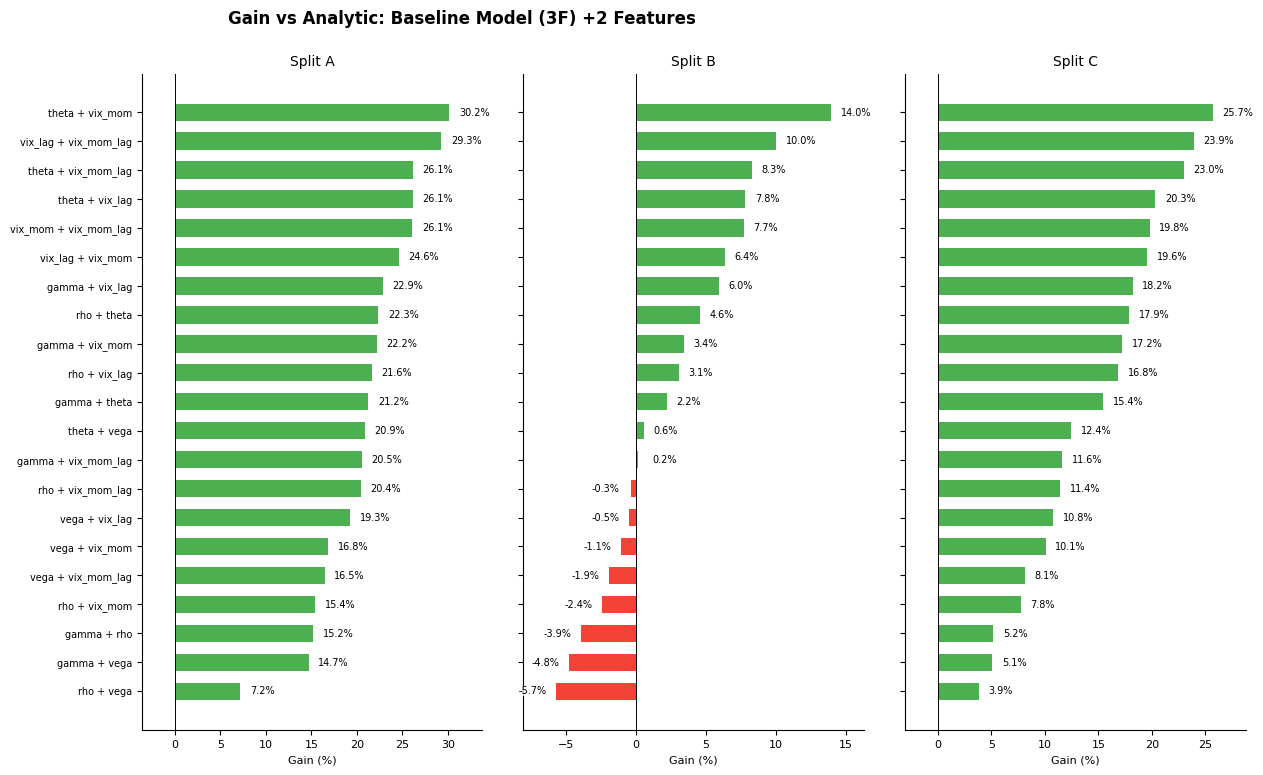

In [6]:
# Compact 2F - 3 splits side-by-side (slide-ready)
two_f = avg_gain[avg_gain["n_features"] == 2].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 8.0), sharey=False)
fig.suptitle("Gain vs Analytic: Baseline Model (3F) +2 Features", fontsize=12, fontweight="bold", y=0.98)

for idx, (ax, split, label) in enumerate(zip(axes, splits, split_labels)):
    data = two_f[two_f[split].notna()].sort_values(split, ascending=True)
    y_labels = data["extra_features"].astype(str).str.replace("+", " + ", regex=False)

    colors = ["#4caf50" if v >= 0 else "#f44336" for v in data[split]]
    bars = ax.barh(y_labels, data[split], color=colors, height=0.6)
    ax.axvline(0, color="black", linewidth=0.7)

    x_min = min(data[split].min(), 0)
    x_max = max(data[split].max(), 0)
    x_span = max(x_max - x_min, 1.0)
    x_pad = max(0.9, x_span * 0.12)
    left_lim = x_min - x_pad
    right_lim = x_max + x_pad
    ax.set_xlim(left_lim, right_lim)

    label_offset = max(0.22, x_span * 0.035)
    zero_guard = max(0.35, x_span * 0.06)
    edge_margin = max(0.12, x_span * 0.02)

    for bar, val in zip(bars, data[split]):
        if val >= 0:
            x_text = max(val + label_offset, zero_guard)
            ha = "left"
        else:
            x_text = min(val - label_offset, -zero_guard)
            ha = "right"

        x_text = min(max(x_text, left_lim + edge_margin), right_lim - edge_margin)

        ax.text(
            x_text,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center",
            ha=ha,
            fontsize=7.0,
            clip_on=False,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.12),
        )

    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Gain (%)", fontsize=8)
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=7)
    if idx > 0:
        ax.tick_params(axis="y", labelleft=False)
    ax.spines[["top", "right"]].set_visible(False)

fig.subplots_adjust(left=0.30, right=0.99, wspace=0.12, top=0.90, bottom=0.08)
plt.savefig(FIG_OUTPUT / "2.x-2F-splits-ABC.png", dpi=150, bbox_inches="tight")
plt.show()



## D vs D_ivlag: Impact of Adding `iv_lag`

In [7]:
# Complete paired table for Split D vs Split D + iv_lag
def feature_key(model_name, drop_iv_lag=False):
    if model_name == "3F":
        return tuple()

    features = model_name.replace("3F+", "").split("+")
    if drop_iv_lag:
        features = [feature for feature in features if feature != "iv_lag"]

    return tuple(sorted(features))


df_D_all = (
    pd.read_csv(OUTPUT / "2.3-fc-rand-D-colab/01-run/metrics_summary.csv")
    .query("Model not in ['Analytic', 'Total']")
    .copy()
)
df_D_ivlag_all = (
    pd.read_csv(OUTPUT / "2.3.1-fc-rand-D-colab-ivlag/01-run/metrics_summary.csv")
    .query("Model not in ['Analytic', 'Total']")
    .copy()
)

df_D_all["pair_key"] = df_D_all["Model"].map(feature_key)
df_D_all["D Gain%"] = df_D_all["Gain_vs_Analytic"].map(parse_gain)

df_D_ivlag_all = df_D_ivlag_all[df_D_ivlag_all["Model"].str.contains("iv_lag", regex=False)].copy()
df_D_ivlag_all["pair_key"] = df_D_ivlag_all["Model"].map(
    lambda model: feature_key(model, drop_iv_lag=True)
)
df_D_ivlag_all["D+iv_lag Gain%"] = df_D_ivlag_all["Gain_vs_Analytic"].map(parse_gain)

df_D_vs_D = (
    df_D_all[["Model", "pair_key", "D Gain%"]]
    .rename(columns={"Model": "Features"})
    .merge(
        df_D_ivlag_all[["pair_key", "D+iv_lag Gain%"]],
        on="pair_key",
        how="inner",
    )
    .drop(columns=["pair_key"])
)

df_D_vs_D["Improvement"] = df_D_vs_D["D+iv_lag Gain%"] - df_D_vs_D["D Gain%"]
df_D_vs_D["Improvement Pct%"] = np.where(
    df_D_vs_D["D Gain%"].ne(0),
    df_D_vs_D["Improvement"] / df_D_vs_D["D Gain%"].abs() * 100,
    np.nan,
)

df_D_vs_D["Rank"] = (
    df_D_vs_D["Improvement Pct%"]
    .rank(ascending=False, method="min")
    .astype("Int64")
)

df_D_vs_D = df_D_vs_D[[
    "Rank",
    "Features",
    "D Gain%",
    "D+iv_lag Gain%",
    "Improvement",
    "Improvement Pct%",
]].sort_values(["Rank", "Features"], ascending=[True, True]).reset_index(drop=True)

output_path = FIG_OUTPUT / "2.x-DvsD-iv-lag.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
df_D_vs_D.to_csv(output_path, index=False)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(
        df_D_vs_D.style
        .format({
            "D Gain%": "{:.2f}%",
            "D+iv_lag Gain%": "{:.2f}%",
            "Improvement": "{:+.2f}",
            "Improvement Pct%": "{:+.1f}%",
        })
        .background_gradient(subset=["D Gain%", "D+iv_lag Gain%"], cmap="RdYlGn")
        .background_gradient(subset=["Improvement", "Improvement Pct%"], cmap="RdYlGn")
        .set_caption("Split D vs Split D+iv_lag (ranked by improvement pct change)")
    )


,Rank,Features,D Gain%,D+iv_lag Gain%,Improvement,Improvement Pct%
0,1,3F+vix_lag+vix_mom_lag+vix_mom+gamma+theta+vega,-38.99%,41.55%,+80.54,+206.6%
1,2,3F+vix_lag+vix_mom_lag+vix_mom+gamma+theta+rho,-38.82%,40.80%,+79.62,+205.1%
2,3,3F+vix_lag+vix_mom_lag+vix_mom+gamma+theta+vega+rho,-12.27%,12.31%,+24.58,+200.3%
3,4,3F+vix_lag+gamma+theta+vega,-15.26%,14.45%,+29.71,+194.7%
4,5,3F+vix_mom_lag+vix_mom+gamma+theta,-14.17%,13.03%,+27.20,+192.0%
5,6,3F+vix_mom+gamma+theta+rho,-11.42%,10.33%,+21.75,+190.5%
6,7,3F+vix_lag+vix_mom_lag+gamma+theta,-25.03%,22.37%,+47.40,+189.4%
7,8,3F+vix_mom+gamma+theta+vega,-20.56%,13.11%,+33.67,+163.8%
8,9,3F+vix_lag+vix_mom_lag+vix_mom+gamma+vega+rho,-51.68%,31.24%,+82.92,+160.4%
9,10,3F+vix_mom+gamma+theta,-22.41%,11.98%,+34.39,+153.5%


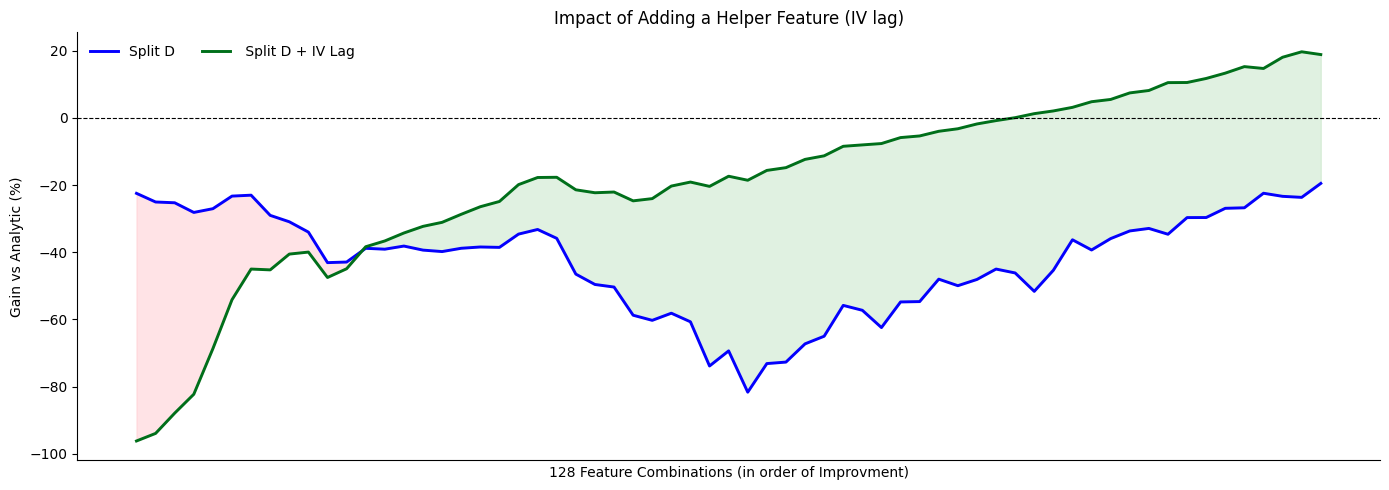

In [ ]:
# D vs D+iv_lag line chart (ordered by lowest to highest pct improvement)
plot_df = df_D_vs_D.sort_values("Improvement Pct%", ascending=True, na_position="last").reset_index(drop=True)

# Drop a couple of extreme rows to reduce edge spikes
if len(plot_df) > 30:
    plot_df = plot_df.iloc[1:-1].reset_index(drop=True)

# Downsample when there are many rows, then smooth with rolling mean
target_points = 80
if len(plot_df) > target_points:
    group_size = int(np.ceil(len(plot_df) / target_points))
    plot_df = (
        plot_df.assign(_group=np.arange(len(plot_df)) // group_size)
        .groupby("_group", as_index=False)[["D Gain%", "D+iv_lag Gain%", "Improvement Pct%"]]
        .mean()
    )

window = 5 if len(plot_df) >= 20 else 3
d_gain = plot_df["D Gain%"].rolling(window=window, center=True, min_periods=1).mean().to_numpy()
divlag_gain = plot_df["D+iv_lag Gain%"].rolling(window=window, center=True, min_periods=1).mean().to_numpy()
gap = divlag_gain - d_gain
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x, d_gain, color="#0400fe", linewidth=2.1, label="Split D")
ax.plot(x, divlag_gain, color="#006f1a", linewidth=2.1, label=" Split D + IV Lag")

ax.fill_between(
    x, d_gain, divlag_gain,
    where=gap >= 0,
    interpolate=True,
    color="#c8e6c9",
    alpha=0.55,
)
ax.fill_between(
    x, d_gain, divlag_gain,
    where=gap < 0,
    interpolate=True,
    color="#ffcdd2",
    alpha=0.55,
)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("128 Feature Combinations (in order of Improvment)")
ax.set_ylabel("Gain vs Analytic (%)")
ax.set_title("Impact of Adding a Helper Feature (IV lag)")
ax.set_xticks([])
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=2)
plt.savefig(FIG_OUTPUT / "2.x-DvsD-iv-lag.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()
